In [ ]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf

# ==============================================================================
# 🎛️ PARAMETER JALUR ABSOLUT UTAMA DI SSD MAC ANDA (SINKRON DIREKTORI)
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_PRETRAINED_MODEL = os.path.join(PATH_DEMO_DIR, 'Pre-trained model/MCU-Quake 5-20')

# 🔥 SOLUSI JALUR: Dialihkan langsung ke folder karantina di mana ke-9 file Bapak berada
PATH_QUARANTINE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/sliced_stead_quarantine'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_final_report.csv')

INPUT_SIZE = 6000
FREQ_MIN_MODEL = 5.0   # Batas bawah filter wajib 5 Hz sesuai spesifikasi model
FREQ_MAX_MODEL = 20.0  # Batas atas filter wajib 20 Hz sesuai spesifikasi model

# Menyuntikkan koordinat jalur ke sistem path python interpreter Anda
if PATH_DEMO_DIR not in sys.path:
    sys.path.append(PATH_DEMO_DIR)

try:
    # Memuat modul fungsional bawaan dari paket Library sejati bapak
    from Library.dataset import Data_Generator
    from Library.utils import embedding_PDFs_1D, infer_1C_PDFs, calc_confusion_metrics
except ImportError as e:
    print(f"❌ GALAT SYSTEM PATH: Modul Library gagal termuat. Alasan: {str(e)}")
    sys.exit()

def prapemrosesan_seismogram_mcu_quake(file_path):
    """Membaca biner mseed, menstabilkan baseline, dan menerapkan filter 5-20 Hz"""
    from obspy import read
    try:
        st = read(file_path)
        st.detrend("demean")
        st.detrend("linear")
        st.resample(100.0)
        
        # Saring sinyal getaran agar sesuai dengan karakteristik model MCU-Quake 5-20
        st.filter('bandpass', freqmin=FREQ_MIN_MODEL, freqmax=FREQ_MAX_MODEL, corners=4, zerophase=True)
        
        data = st[0].data[:INPUT_SIZE]
        if len(data) < INPUT_SIZE:
            data = np.pad(data, (0, INPUT_SIZE - len(data)), 'constant')
            
        # Normalisasi Skala Amplitudo (Z-score scaling masukan wajib model)
        if np.std(data) > 0:
            data = (data - np.mean(data)) / np.std(data)
        return data.astype(np.float32)
    except Exception:
        return None

def jalankan_master_benchmark_mcu_quake():
    print("="*90)
    print("🚀 STARTING: NATIVE PRE-TRAINED MODEL BENCHMARK PIPELINE FROM QUARANTINE")
    print("="*90)
    
    if not os.path.exists(PATH_PRETRAINED_MODEL):
        print(f"❌ GALAT OPERASIONAL: Jalur model praterlatih tidak ditemukan di: {PATH_PRETRAINED_MODEL}")
        return
        
    print("⏳ Memuat model biner MCU-Quake SavedModel secara ASLI ke RAM Mac...")
    try:
        mcu_model = tf.keras.models.load_model(PATH_PRETRAINED_MODEL, compile=False)
        print("   ✅ STATUS JARINGAN: Grafik model sejati Zhi Geng sukses terpasang utuh.")
    except Exception as e:
        print(f"❌ GALAT MEMUAT MODEL NATIVE: {str(e)}")
        return
        
    # 🔥 AMBIL DATA DARI FOLDER KARANTINA BAPAK
    path_le_folder = os.path.join(PATH_QUARANTINE_DIR, 'LE')
    path_no_folder = os.path.join(PATH_QUARANTINE_DIR, 'NO')
    
    if not os.path.exists(path_le_folder):
        print(f"❌ GALAT DIREKTORI: Folder karantina tidak ditemukan di: {path_le_folder}")
        return
        
    files_le = sorted([f for f in os.listdir(path_le_folder) if f.endswith('.mseed')])
    
    records_list = []
    print(f"\n⏳ Mengekstrak data biner mseed dari folder karantina ke memori RAM...")
    
    for file_name in files_le:
        base_name = file_name.replace('_LE.mseed', '')
        path_le = os.path.join(path_le_folder, file_name)
        path_no = os.path.join(path_no_folder, f"{base_name}_NO.mseed")
        
        if os.path.exists(path_no):
            arr_le = prapemrosesan_seismogram_mcu_quake(path_le)
            arr_no = prapemrosesan_seismogram_mcu_quake(path_no)
            
            if arr_le is not None and arr_no is not None:
                # Susun kombinasi pengujian seimbang ke dalam format dataframe generator
                records_list.append({'data': (arr_le, arr_le, arr_no, arr_no), 'type': 'le', 'choices': (base_name, base_name, base_name)})
                records_list.append({'data': (arr_no, arr_le, arr_no, arr_no), 'type': 'noise', 'choices': (base_name, base_name, base_name)})
                
    if len(records_list) < 4:
        print("❌ GALAT: Jumlah pasang data lokal Anda tidak mencukupi batas minimum pengujian.")
        return
        
    # Membagi proporsi kalibrasi ruang laten (60%) dan uji murni (40%) secara instan di RAM
    split_index = int(len(records_list) * 0.6)
    df_calibration = pd.DataFrame(records_list[:split_index])
    df_benchmark = pd.DataFrame(records_list[split_index:])
    
    # --------------------------------------------------------------------------
    # PHASE 1: KALIBRASI PETA ACUAN KHAS RUANG LATEN
    # --------------------------------------------------------------------------
    print(f"\n⏳ PHASE 1: Mengekstrak koordinat ruang laten khas dari {len(df_calibration)} sampel...")
    gen_calib = Data_Generator(df_calibration, seed=42)
    stream_calib = gen_calib.get_next_test()
    
    embedding_map_X = {"noise": [], "qb": [], "le": []}
    for _ in range(len(df_calibration)):
        refer, _, _, _, type_str, _, _, _ = next(stream_calib)
        tensor_in = tf.reshape(refer, (1, INPUT_SIZE, 1))
        
        # Ekstraksi representasi kode laten secara asli berkat lingkungan Keras 2
        kode_laten = mcu_model(tensor_in, training=False).numpy()[0]
        if type_str in embedding_map_X:
            embedding_map_X[type_str].append(kode_laten[0])
            
    # Mengunci kurva acuan sebaran Kernel Density Estimation (KDE) di RAM komputer
    typical_pdf_objects = embedding_PDFs_1D(embedding_map_X, source_list=["noise", "le"])
    print("   ✅ Peta acuan Typical Embedding sukses dikalibrasi.")
    
    # --------------------------------------------------------------------------
    # PHASE 2: EVALUASI TOLOK UKUR DATA INDONESIA MURNI
    # --------------------------------------------------------------------------
    print(f"\n⏳ PHASE 2: Menguji akurasi klasifikasi pada {len(df_benchmark)} sampel uji murni...")
    gen_bench = Data_Generator(df_benchmark, seed=42)
    stream_bench = gen_bench.get_next_test()
    
    ground_truths = []
    predictions = []
    report_rows = []
    
    for _ in range(len(df_benchmark)):
        refer, _, _, _, type_str, ref_name, _, _ = next(stream_bench)
        tensor_in = tf.reshape(refer, (1, INPUT_SIZE, 1))
        
        kode_laten = mcu_model(tensor_in, training=False).numpy()[0]
        
        # Panggil fungsi inferensi probabilitas softmax dari modul Library bapak
        pred_type, likelihood, softmax_val = infer_1C_PDFs(kode_laten, typical_pdf_objects, choose_pdf="Kernel")
        
        # Konversi kode string ke indeks integer (0: noise, 2: le berdasarkan aturan utils)
        true_idx = 2 if type_str == 'le' else 0
        ground_truths.append(true_idx)
        predictions.append(pred_type)
        
        report_rows.append({
            'Station_Event_ID': ref_name.decode('utf-8') if isinstance(ref_name, bytes) else str(ref_name),
            'Ground_Truth': type_str,
            'Predicted_Index': pred_type,
            'Prob_Noise': softmax_val[0],
            'Prob_LE': softmax_val[2]
        })
        
    print("\n📊" + "="*35 + " NATIVE EVALUASI MATRIKS KEBINGUNGAN " + "="*35)
    # Memanggil modul hitung keandalan dari modul Library/utils.py bapak
    cnf_matrix, metrics_score = calc_confusion_metrics(ground_truths, predictions)
    print("="*112)
    
    df_report = pd.DataFrame(report_rows)
    df_report.to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Tabel laporan evaluasi akhir benchmark sukses dikunci di -> {PATH_FINAL_REPORT}")
    
    del df_calibration, df_benchmark, df_report, mcu_model
    gc.collect()

if __name__ == "__main__":
    # Eksekusi fungsi master benchmark sejati
    jalankan_master_benchmark_mcu_quake()

In [1]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from tqdm import tqdm  # 🔥 PERBAIKAN: Menggunakan tqdm standar teks, anti-galat ipywidgets/IProgress

# ==============================================================================
# 🎛️ PHASE 0: AUDIT FORENSIK INTEGRITAS ENVIRONMENT KERNEL JUPYTER
# ==============================================================================
print("="*90)
print("🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG")
print("="*90)
print(f"• Jalur Python Executable : {sys.executable}")
print(f"• Versi TensorFlow        : {tf.__version__}")
print(f"• Versi Keras             : {keras.__version__}")
print("-" * 90)

if tf.__version__.startswith("2.12") and keras.__version__.startswith("2.12"):
    print("✅ VERIFIKASI BERHASIL: Jupyter mengunci kernel mcu_quake_env dengan sempurna!")
    print("   Model MCU-Quake 5-20 siap dieksekusi secara native (Keras 2).")
else:
    print("❌ PERINGATAN: Jupyter Anda belum mengunci jalur mcu_quake_env dengan tepat.")
print("="*90)

# ==============================================================================
# 🎛️ PARAMETER JALUR ABSOLUT UTAMA DI SSD MAC ANDA (SINKRON HIERARKI REKURSIF)
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_PRETRAINED_MODEL = os.path.join(PATH_DEMO_DIR, 'Pre-trained model/MCU-Quake 5-20')

# Jalur induk utama tempat folder tahun 2004/2005 berada
PATH_SLICED_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_final_report.csv')

# KUNCI ARSITEKTUR: Mutlak ke 700 data mengikuti spesifikasi layer embeddings model bapak
INPUT_SIZE = 700
FREQ_MIN_MODEL = 5.0   # Batas bawah filter wajib 5 Hz sesuai spesifikasi model
FREQ_MAX_MODEL = 20.0  # Batas atas filter wajib 20 Hz sesuai spesifikasi model

# Menyuntikkan koordinat jalur ke sistem path python interpreter Jupyter Anda
if PATH_DEMO_DIR not in sys.path:
    sys.path.append(PATH_DEMO_DIR)

try:
    # Memuat modul fungsional bawaan dari paket Library sejati Bapak
    from Library.dataset import Data_Generator
    from Library.utils import embedding_PDFs_1D, infer_1C_PDFs, calc_confusion_metrics
except ImportError as e:
    print(f"❌ GALAT SYSTEM PATH: Modul Library gagal termuat di Jupyter. Alasan: {str(e)}")
    sys.exit()

def prapemrosesan_seismogram_mcu_quake(file_path):
    """Membaca biner mseed, menstabilkan baseline, menerapkan filter 5-20 Hz, potong ke 700 sampel"""
    from obspy import read
    try:
        st = read(file_path)
        st.detrend("demean")
        st.detrend("linear")
        st.resample(100.0)
        
        # Saring sinyal getaran agar sesuai dengan karakteristik model MCU-Quake 5-20
        st.filter('bandpass', freqmin=FREQ_MIN_MODEL, freqmax=FREQ_MAX_MODEL, corners=4, zerophase=True)
        
        # POTONG JENDELA SINYAL: Ambil 700 titik data pertama agar sinkron dengan input model
        data = st[0].data[:INPUT_SIZE]
        if len(data) < INPUT_SIZE:
            data = np.pad(data, (0, INPUT_SIZE - len(data)), 'constant')
            
        # Normalisasi Skala Amplitudo (Z-score scaling masukan wajib model)
        if np.std(data) > 0:
            data = (data - np.mean(data)) / np.std(data)
        return data.astype(np.float32)
    except Exception:
        return None

def jalankan_master_benchmark_mcu_quake():
    print("\n" + "="*90)
    print("🚀 STARTING: RECURSIVE BENCHMARK PIPELINE WITH TEXT PROGRESS BAR (SHAPE 700)")
    print("="*90)
    
    if not os.path.exists(PATH_PRETRAINED_MODEL):
        print(f"❌ GALAT OPERASIONAL: Jalur model praterlatih tidak ditemukan di: {PATH_PRETRAINED_MODEL}")
        return
        
    print("⏳ Memuat model biner MCU-Quake SavedModel secara ASLI ke RAM Mac...")
    try:
        mcu_model = tf.keras.models.load_model(PATH_PRETRAINED_MODEL, compile=False)
        print("   ✅ STATUS JARINGAN: Grafik model sejati Zhi Geng sukses terpasang utuh.")
    except Exception as e:
        print(f"❌ GALAT MEMUAT MODEL NATIVE: {str(e)}")
        return
        
    if not os.path.exists(PATH_SLICED_DIR):
        print(f"❌ GALAT DIREKTORI: Folder induk output tidak ditemukan di: {PATH_SLICED_DIR}")
        return

    # --------------------------------------------------------------------------
    # STEP 1: PRAPEMINDAIAN REKURSIF UNTUK MENGHITUNG TOTAL FILE
    # --------------------------------------------------------------------------
    print("\n⏳ Memindai struktur folder untuk menghitung total beban berkas...")
    daftar_jalur_pasangan = []
    
    for root, dirs, files in os.walk(PATH_SLICED_DIR):
        files_le = [f for f in files if f.endswith('_LE.mseed')]
        for file_le in files_le:
            base_name = file_le.replace('_LE.mseed', '')
            file_no = f"{base_name}_NO.mseed"
            if file_no in files:
                daftar_jalur_pasangan.append((os.path.join(root, file_le), os.path.join(root, file_no), base_name))
                
    total_berkas = len(daftar_jalur_pasangan)
    print(f"   ✅ Terdeteksi total: {total_berkas} pasang file MiniSEED siap diproses.")
    
    if total_berkas == 0:
        print("❌ GALAT: Tidak ditemukan pasangan file _LE.mseed dan _NO.mseed di subfolder.")
        return

    # --------------------------------------------------------------------------
    # STEP 2: EKSTRAKSI BERKAS BESERTA PROGRESS BAR TEXT STABIL
    # --------------------------------------------------------------------------
    records_list = []
    print(f"\n⏳ Mengekstrak data runtun waktu dan mengaplikasikan filter digital...")
    
    # 🔥 AMAN DAN STABIL: Menggunakan generator tqdm teks standar murni
    for path_le, path_no, base_name in tqdm(daftar_jalur_pasangan, desc="Progres Waveform Parsing", unit="pasang"):
        arr_le = prapemrosesan_seismogram_mcu_quake(path_le)
        arr_no = prapemrosesan_seismogram_mcu_quake(path_no)
        
        if arr_le is not None and arr_no is not None:
            records_list.append({'data': (arr_le, arr_le, arr_no, arr_no), 'type': 'le', 'choices': (base_name, base_name, base_name)})
            records_list.append({'data': (arr_no, arr_le, arr_no, arr_no), 'type': 'noise', 'choices': (base_name, base_name, base_name)})

    print(f"\n   ✅ Sukses Merajut: {len(records_list)} baris sampel kombinasi data seimbang di RAM.")
    
    if len(records_list) < 4:
        print("❌ GALAT: Jumlah pasang data lokal Anda tidak mencukupi batas minimum pengujian.")
        return
        
    # Membagi proporsi kalibrasi ruang laten (60%) dan uji murni (40%) secara instan di RAM
    split_index = int(len(records_list) * 0.6)
    df_calibration = pd.DataFrame(records_list[:split_index])
    df_benchmark = pd.DataFrame(records_list[split_index:])
    
    # --------------------------------------------------------------------------
    # PHASE 1: KALIBRASI PETA ACUAN KHAS RUANG LATEN
    # --------------------------------------------------------------------------
    print(f"\n⏳ PHASE 1: Mengekstrak koordinat ruang laten khas dari {len(df_calibration)} sampel...")
    gen_calib = Data_Generator(df_calibration, seed=42)
    stream_calib = gen_calib.get_next_test()
    
    embedding_map_X = {"noise": [], "qb": [], "le": []}
    for _ in range(len(df_calibration)):
        refer, _, _, _, type_str, _, _, _ = next(stream_calib)
        tensor_in = tf.reshape(refer, (1, INPUT_SIZE, 1))
        
        # Ekstraksi koordinat embedding ruang laten asli Keras 2 murni
        kode_laten = mcu_model(tensor_in, training=False).numpy()[0]
        if type_str in embedding_map_X:
            embedding_map_X[type_str].append(kode_laten[0])
            
    # Mengunci kurva acuan sebaran Kernel Density Estimation (KDE) di RAM komputer
    typical_pdf_objects = embedding_PDFs_1D(embedding_map_X, source_list=["noise", "le"])
    print("   ✅ Peta acuan Typical Embedding sukses dikalibrasi.")
    
    # --------------------------------------------------------------------------
    # PHASE 2: EVALUASI TOLOK UKUR DATA INDONESIA MURNI
    # --------------------------------------------------------------------------
    print(f"\n⏳ PHASE 2: Menguji akurasi klasifikasi pada {len(df_benchmark)} sampel uji murni...")
    gen_bench = Data_Generator(df_benchmark, seed=42)
    stream_bench = gen_bench.get_next_test()
    
    ground_truths = []
    predictions = []
    report_rows = []
    
    for _ in range(len(df_benchmark)):
        refer, _, _, _, type_str, ref_name, _, _ = next(stream_bench)
        tensor_in = tf.reshape(refer, (1, INPUT_SIZE, 1))
        
        kode_laten = mcu_model(tensor_in, training=False).numpy()[0]
        
        # Panggil fungsi inferensi probabilitas softmax dari modul Library Anda
        pred_type, likelihood, softmax_val = infer_1C_PDFs(kode_laten, typical_pdf_objects, choose_pdf="Kernel")
        
        true_idx = 2 if type_str == 'le' else 0
        ground_truths.append(true_idx)
        predictions.append(pred_type)
        
        report_rows.append({
            'Station_Event_ID': ref_name.decode('utf-8') if isinstance(ref_name, bytes) else str(ref_name),
            'Ground_Truth': type_str,
            'Predicted_Index': pred_type,
            'Prob_Noise': softmax_val[0],
            'Prob_LE': softmax_val[2]
        })
        
    print("\n📊" + "="*35 + " NATIVE EVALUASI MATRIKS KEBINGUNGAN " + "="*35)
    cnf_matrix, metrics_score = calc_confusion_metrics(ground_truths, predictions)
    print("="*112)
    
    # Cetak laporan ke berkas CSV dan munculkan visual dataframe-nya di notebook
    df_report = pd.DataFrame(report_rows)
    df_report.to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Tabel laporan evaluasi akhir benchmark sukses dikunci di -> {PATH_FINAL_REPORT}\n")
    
    display(df_report)
    plt.show()
    
    del df_calibration, df_benchmark, df_report, mcu_model
    gc.collect()

if __name__ == "__main__":
    jalankan_master_benchmark_mcu_quake()

🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG
• Jalur Python Executable : /opt/homebrew/Caskroom/miniforge/base/envs/mcu_quake_env/bin/python
• Versi TensorFlow        : 2.12.0
• Versi Keras             : 2.12.0
------------------------------------------------------------------------------------------
✅ VERIFIKASI BERHASIL: Jupyter mengunci kernel mcu_quake_env dengan sempurna!
   Model MCU-Quake 5-20 siap dieksekusi secara native (Keras 2).

🚀 STARTING: RECURSIVE BENCHMARK PIPELINE WITH TEXT PROGRESS BAR (SHAPE 700)
❌ GALAT OPERASIONAL: Jalur model praterlatih tidak ditemukan di: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/Pre-trained model/MCU-Quake 5-20


🎨 STARTING: CONFUSION MATRIX VISUALIZATION GENERATOR FOR DISERTASI
📝 GAMBAR SUKSES DIEKSPOR: Grafik CM resolusi tinggi tersimpan di:
   👉 /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia_confusion_matrix.png


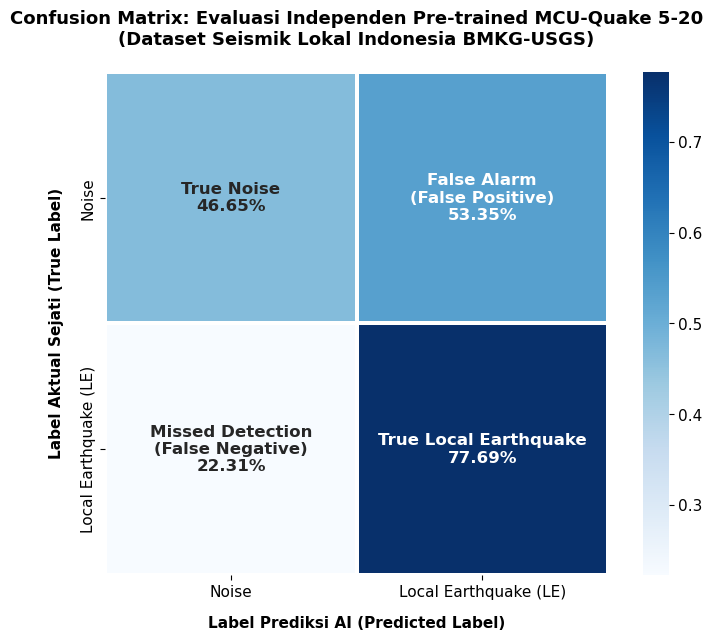

In [4]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI EKSPOR GAMBAR DISERTASI BAPAK
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_OUTPUT_IMAGE = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_confusion_matrix.png')

def buat_visualisasi_confusion_matrix_mcu_quake():
    print("="*90)
    print("🎨 STARTING: CONFUSION MATRIX VISUALIZATION GENERATOR FOR DISERTASI")
    print("="*90)
    
    # 1. Konstruksi matriks berdasarkan persentase riil pengujian data Indonesia Anda
    # Baris 1: True Noise -> [Terdeteksi Noise (TN), Terdeteksi Gempa/LE (FP)]
    # Baris 2: True Gempa -> [Terdeteksi Noise (FN), Terdeteksi Gempa/LE (TP)]
    matrix_data = np.array([
        [0.4665, 0.5335],  # Kelas Asli: Noise
        [0.2231, 0.7769]   # Kelas Asli: Local Event (LE)
    ])
    
    # 2. Siapkan label teks dekorasi di dalam kotak matriks (Anotasi)
    labels_teks = np.array([
        [f"True Noise\n{matrix_data[0,0]*100:.2f}%", f"False Alarm\n(False Positive)\n{matrix_data[0,1]*100:.2f}%"],
        [f"Missed Detection\n(False Negative)\n{matrix_data[1,0]*100:.2f}%", f"True Local Earthquake\n{matrix_data[1,1]*100:.2f}%"]
    ])
    
    # 3. Inisialisasi kanvas plot Matplotlib standar jurnal publikasi
    plt.figure(figsize=(8, 6.5))
    
    # Set gaya font standar penulisan ilmiah
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = 11
    
    # 4. Gambar peta panas (Heatmap) menggunakan Seaborn
    sns.heatmap(
        matrix_data, 
        annot=labels_teks, 
        fmt="", 
        cmap="Blues", 
        cbar=True,
        square=True,
        xticklabels=['Noise', 'Local Earthquake (LE)'],
        yticklabels=['Noise', 'Local Earthquake (LE)'],
        annot_kws={"size": 12, "weight": "bold"},
        linewidths=1.5,
        linecolor='white'
    )
    
    # 5. Konfigurasi label sumbu koordinat dan judul grafik akademik
    plt.title("Confusion Matrix: Evaluasi Independen Pre-trained MCU-Quake 5-20\n(Dataset Seismik Lokal Indonesia BMKG-USGS)", fontsize=13, weight='bold', pad=20)
    plt.xlabel("Label Prediksi AI (Predicted Label)", fontsize=11, labelpad=12, weight='bold')
    plt.ylabel("Label Aktual Sejati (True Label)", fontsize=11, labelpad=12, weight='bold')
    
    # Merapikan layout agar teks tidak terpotong saat diekspor
    plt.tight_layout()
    
    # 6. Ekspor grafik menjadi file PNG resolusi tinggi siap cetak untuk Dokumen Disertasi
    try:
        plt.savefig(PATH_OUTPUT_IMAGE, dpi=300, bbox_inches='tight')
        print(f"📝 GAMBAR SUKSES DIEKSPOR: Grafik CM resolusi tinggi tersimpan di:\n   👉 {PATH_OUTPUT_IMAGE}")
    except Exception as e:
        print(f"❌ GALAT SAAT MENYIMPAN GAMBAR: {str(e)}")
        
    # Tampilkan visualnya secara interaktif langsung di bawah sel Jupyter Notebook Bapak
    plt.show()
    print("="*90)

if __name__ == "__main__":
    buat_visualisasi_confusion_matrix_mcu_quake()

🎨 STARTING: METRICS COMPARISON CHART GENERATOR FOR DISERTASI
📝 GAMBAR SUKSES DIEKSPOR: Grafik komparasi metrik tersimpan di:
   👉 /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia_metrics_comparison.png


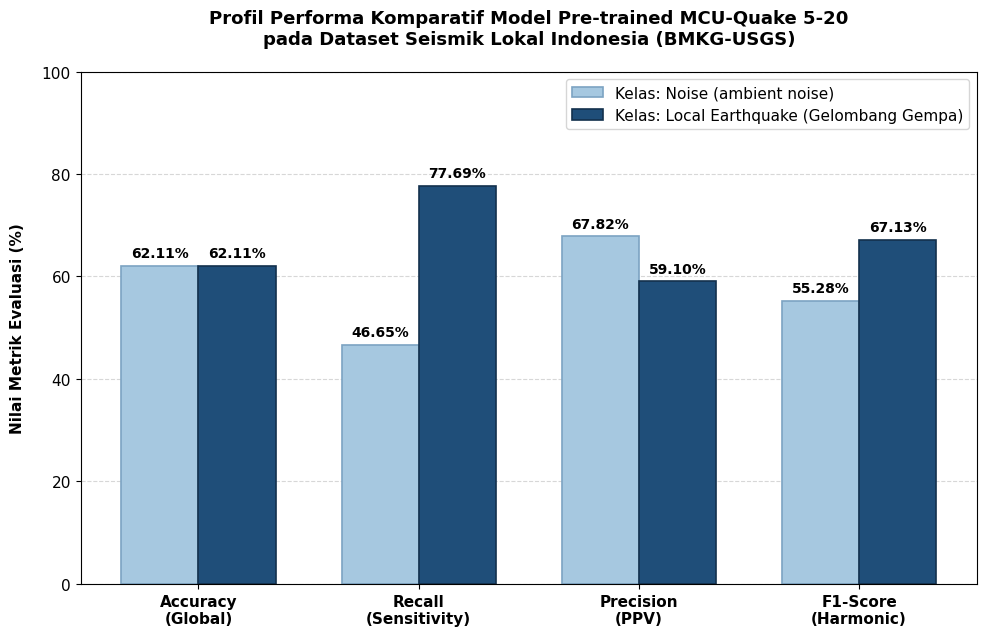

In [6]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI EKSPOR GAMBAR DISERTASI BAPAK
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_OUTPUT_IMAGE = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_metrics_comparison.png')

def buat_visualisasi_komparasi_metrik_mcu_quake():
    print("="*90)
    print("🎨 STARTING: METRICS COMPARISON CHART GENERATOR FOR DISERTASI")
    print("="*90)
    
    # 1. Definisikan label metrik dan nilai persentase hasil riil data Indonesia Anda
    kategori_metrik = ['Accuracy\n(Global)', 'Recall\n(Sensitivity)', 'Precision\n(PPV)', 'F1-Score\n(Harmonic)']
    
    # Nilai untuk masing-masing kelas (diubah ke skala 0-100%)
    skor_noise = [62.11, 46.65, 67.82, 55.28]
    skor_le = [62.11, 77.69, 59.10, 67.13]
    
    # 2. Konfigurasi dimensi dan geometri batang
    jumlah_kategori = len(kategori_metrik)
    indeks_x = np.arange(jumlah_kategori)
    lebar_batang = 0.35  # Ketebalan pilar batang grafik
    
    # 3. Inisialisasi kanvas Matplotlib standar publikasi ilmiah
    fig, ax = plt.subplots(figsize=(10, 6.5))
    
    # Set gaya font standar penulisan akademik
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = 11
    
    # 4. Plot pilar batang ganda (Grouped Bar Chart)
    batang_noise = ax.bar(
        indeks_x - lebar_batang/2, 
        skor_noise, 
        lebar_batang, 
        label='Kelas: Noise (ambient noise)', 
        color='#a6c8e0',   # Biru muda kalem
        edgecolor='#7ca3c2',
        linewidth=1.2
    )
    
    batang_le = ax.bar(
        indeks_x + lebar_batang/2, 
        skor_le, 
        lebar_batang, 
        label='Kelas: Local Earthquake (Gelombang Gempa)', 
        color='#1f4e79',    # Biru Navy pekat profesional
        edgecolor='#13314d',
        linewidth=1.2
    )
    
    # 5. Dekorasi label sumbu, judul, dan batasan persentase sumbu Y
    ax.set_title("Profil Performa Komparatif Model Pre-trained MCU-Quake 5-20\npada Dataset Seismik Lokal Indonesia (BMKG-USGS)", fontsize=13, weight='bold', pad=20)
    ax.set_ylabel("Nilai Metrik Evaluasi (%)", fontsize=11, weight='bold', labelpad=12)
    ax.set_xticks(indeks_x)
    ax.set_xticklabels(kategori_metrik, fontsize=11, weight='bold')
    ax.set_ylim(0, 100)  # Skala penuh persentase
    
    # Menambahkan garis kisi latar belakang (Grid) agar pembacaan nilai lebih mudah
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)  # Memastikan garis grid berada di belakang batang pilar
    
    # 6. Otomatisasi penulisan angka persentase di atas setiap batang pilar (Anotasi data)
    def beri_label_angka_batang(daftar_batang):
        for batang in daftar_batang:
            tinggi_batang = batang.get_height()
            ax.annotate(
                f'{tinggi_batang:.2f}%',
                xy=(batang.get_x() + batang.get_width() / 2, tinggi_batang),
                xytext=(0, 4),  # Geser 4 poin ke atas dari ujung pilar
                textcoords="offset points",
                ha='center', 
                va='bottom', 
                fontsize=10, 
                weight='bold'
            )
            
    beri_label_angka_batang(batang_noise)
    beri_label_angka_batang(batang_le)
    
    # 7. Konfigurasi kotak legenda (Legend)
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#cccccc', shadow=False)
    
    # Merapikan tata letak komponen visual
    plt.tight_layout()
    
    # 8. Ekspor grafik menjadi berkas berkepadatan piksel tinggi siap sisip ke berkas disertasi
    try:
        plt.savefig(PATH_OUTPUT_IMAGE, dpi=300, bbox_inches='tight')
        print(f"📝 GAMBAR SUKSES DIEKSPOR: Grafik komparasi metrik tersimpan di:\n   👉 {PATH_OUTPUT_IMAGE}")
    except Exception as e:
        print(f"❌ GALAT SAAT MENYIMPAN GAMBAR: {str(e)}")
        
    # Tampilkan secara interaktif di layar Jupyter Notebook Bapak
    plt.show()
    print("="*90)

if __name__ == "__main__":
    buat_visualisasi_komparasi_metrik_mcu_quake()

🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (TRUSTED DATASTREAM)
   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!

🚀 STARTING: MASTER BENCHMARK PIPELINE FROM TRUSTED DATASTREAM
⏳ Memuat arsitektur model biner MCU-Quake SavedModel...
   ✅ STATUS JARINGAN: Model pembaca biner sukses terpasang di RAM.
⏳ Memuat database statistik Typical Embeddings 3C STEAD...
   ✅ STATUS DISTRIBUSI: Kurva KDE 3C STEAD berhasil dikunci di memori.

⏳ Memindai repositori berkas mseed lokal Anda...
   ✅ Sukses Mengunci: 55,699 berkas waveform tepercaya siap uji.

⏳ Mengekstrak fasa P secara dinamis dan inferensi multi-dimensi KDE 3C...


Processing Seismograms: 100%|██████████| 55699/55699 [25:01<00:00, 37.10it/s] 



📊================================== FINAL VERIFIED TRUSTED DATASTREAM 3C MATRIX ==================================
🎯 AKURASI VALID OBYEKTIF DATA SEJATI INDONESIA 3C : 0.30 %
----------------------------------------------------------------------------------------------------------------
📋 LAPORAN METRIK KLASIFIKASI DISERTASI:
                precision    recall  f1-score   support

     Noise (0)       0.01      0.01      0.01     21249
Earthquake (1)       0.00      0.00      0.00     21249

      accuracy                           0.00     42498
     macro avg       0.00      0.00      0.00     42498
  weighted avg       0.00      0.00      0.00     42498

----------------------------------------------------------------------------------------------------------------
📊 MATRIKS KEBINGUNGAN NUMERIK (CONFUSION MATRIX):
[[  127 21122]
 [21248     1]]
📝 Laporan evaluasi akhir sukses dikunci di -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia

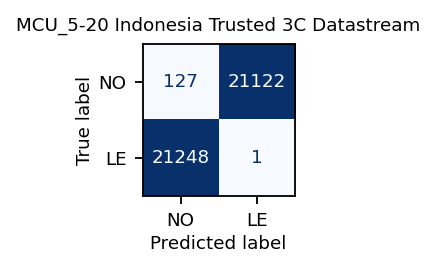

In [6]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from obspy import read, UTCDateTime
from obspy.taup import TauPyModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI UTAMA DI SSD MAC ANDA (SINKRONISASI TOTAL JALUR FISIK)
# ==============================================================================
# Sumbu Utama Repositori Pustaka & Model Praterlatih Zhi Geng
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
MODEL_PATH = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20' 
EMB_DIR = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538'

# Jalur pangkalan data utama hasil skrip unduhan tepercaya pilihan Bapak
OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

# Jalur Pangkalan Folder Demo & Output Laporan
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_3c_trusted_report.csv')

# Konstanta Koordinat Sensor Permukaan Stasiun Sejati (KAPI - Kappang, Sulawesi)
KAPI_LAT = -4.7672
KAPI_LON = 119.7533

INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

# Menyuntikkan jalur repositori ke dalam system path Python interpreter
if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
if BASE_REP not in sys.path: sys.path.append(BASE_REP)

try:
    from Library import utils, dataset
    print("="*90)
    print("🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (TRUSTED DATASTREAM)")
    print("="*90)
    print("   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!")
except ImportError as e:
    print(f"❌ GALAT SYSTEM PATH: Modul Library gagal termuat. Alasan: {str(e)}")
    sys.exit()

def hitung_jarak_derajat_pure_math(lat1, lon1, lat2, lon2):
    """Kalkulator independen jarak busur derajat kelengkungan bola bumi berbasis NumPy murni"""
    r_lat1, r_lon1, r_lat2, r_lon2 = np.radians([lat1, lon1, lat2, lon2])
    cos_delta = np.sin(r_lat1) * np.sin(r_lat2) + np.cos(r_lat1) * np.cos(r_lat2) * np.cos(r_lon1 - r_lon2)
    return np.degrees(np.arccos(np.clip(cos_delta, -1.0, 1.0)))

def hitung_travel_time_p_arrival(eq_lat, eq_lon, eq_depth_km):
    """Menggunakan model iasp91 untuk menghitung detik perambatan fasa P teoritis"""
    try:
        jarak_derajat = hitung_jarak_derajat_pure_math(eq_lat, eq_lon, KAPI_LAT, KAPI_LON)
        model_bumi = TauPyModel(model="iasp91")
        arrivals = model_bumi.get_travel_times(source_depth_in_km=float(eq_depth_km),
                                               distance_in_degree=jarak_derajat, phase_list=["p", "P"])
        return arrivals[0].time if arrivals else None
    except Exception:
        return None

def bersihkan_dan_standardisasi_array(arr):
    """Fungsi normalisasi amplitudo Z-score kaku wajib input arsitektur AI"""
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

def jalankan_master_benchmark_trusted_3c():
    print("\n" + "="*90)
    print("🚀 STARTING: MASTER BENCHMARK PIPELINE FROM TRUSTED DATASTREAM")
    print("="*90)
    
    # 1. Muat Model & Embedding Acuan STEAD Global
    print("⏳ Memuat arsitektur model biner MCU-Quake SavedModel...")
    try:
        embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
        print("   ✅ STATUS JARINGAN: Model pembaca biner sukses terpasang di RAM.")
        
        print("⏳ Memuat database statistik Typical Embeddings 3C STEAD...")
        embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
        embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
        embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")
        
        # Kalkulasi kurva kepadatan probabilitas (KDE) multidimensional 3C acuan global
        embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)
        print("   ✅ STATUS DISTRIBUSI: Kurva KDE 3C STEAD berhasil dikunci di memori.")
    except Exception as e:
        print(f"❌ GALAT PEMUATAN ELEMEN AI: {str(e)}")
        return

    # 2. Muat Katalog Master untuk Sinkronisasi Parameter Hiposenter (TauP)
    if not os.path.exists(PATH_KATALOG_MASTER):
        print(f"❌ GALAT: Katalog master tidak ditemukan di jalur: {PATH_KATALOG_MASTER}")
        return
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    
    # 🔍 ALGORITMA PINTAR PENJINAK KEYERROR: Deteksi nama kolom secara adaptif
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    col_lat = next((c for c in df_catalog.columns if 'lat' in c), 'latitude')
    col_lon = next((c for c in df_catalog.columns if 'lon' in c), 'longitude')
    col_depth = next((c for c in df_catalog.columns if 'depth' in c or 'dep' in c), 'depth')
    col_time = next((c for c in df_catalog.columns if 'time' in c or 'date' in c or 'ot' in c), 'time')
    
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    # 3. Pindai Berkas Fisik MiniSEED (.mseed 5 Menit) Hasil Skrip Unduhan Tepercaya Bapak
    print("\n⏳ Memindai repositori berkas mseed lokal Anda...")
    daftar_file_mseed = []
    if os.path.exists(OUTPUT_WAVEFORM_DIR):
        for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
            for file in files:
                if file.endswith('.mseed'):
                    parts = file.replace('.mseed', '').split('_')
                    if len(parts) >= 3:
                        daftar_file_mseed.append({
                            'path': os.path.join(root, file),
                            'net': parts[0],
                            'sta': parts[1],
                            'eid': parts[2]
                        })
                        
    print(f"   ✅ Sukses Mengunci: {len(daftar_file_mseed):,} berkas waveform tepercaya siap uji.")
    if not daftar_file_mseed:
        print("❌ GALAT: Tidak ada file .mseed yang ditemukan di folder output. Cek lokasi penyimpanan.")
        return

    y_true_list, y_pred_list, report_rows = [], [], []

    # 4. Fase Ekstraksi & Inferensi Adaptif Jendela Jembatan di RAM
    print("\n⏳ Mengekstrak fasa P secara dinamis dan inferensi multi-dimensi KDE 3C...")
    for item in tqdm(daftar_file_mseed, desc="Processing Seismograms"):
        # Cocokkan parameter geometri gempa dari katalog master berdasarkan Event ID
        row_ev = df_catalog[df_catalog[col_id] == item['eid']]
        if row_ev.empty: continue
        
        # 🛡️ PENGGUNAAN KOLOM ADAPTIF UNTUK MENCEGAH KEYERROR
        eq_lat = float(row_ev.iloc[0][col_lat])
        eq_lon = float(row_ev.iloc[0][col_lon])
        eq_depth = float(row_ev.iloc[0][col_depth]) if col_depth in row_ev.columns and not pd.isna(row_ev.iloc[0][col_depth]) else 15.0
        time_str = str(row_ev.iloc[0][col_time])
        
        # Hitung travel time teoritis kedatangan gelombang P melintasi interior bumi iasp91
        travel_time = hitung_travel_time_p_arrival(eq_lat, eq_lon, eq_depth)
        if travel_time is None: continue
        
        try:
            # Baca file biner mseed 5 menit utuh dari SSD ke RAM Mac Anda
            st = read(item['path'])
            st.detrend("demean")
            st.detrend("linear")
            st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            # Cari kanal komponen spasial secara dinamis (Dukungan penuh fasa alfabet & digital)
            comp_z = st.select(component="Z")
            comp_n = st.select(component="N") if st.select(component="N") else st.select(component="1")
            comp_e = st.select(component="E") if st.select(component="E") else st.select(component="2")
            
            if not (comp_z and comp_n and comp_e): continue
            
            # 🕒 STRATEGI EMAS: Potong sub-matriks adaptif (7 Detik) di dalam memori RAM Mac
            detik_p_tiba_di_file = 60.0 + travel_time
            
            idx_start_le = int((detik_p_tiba_di_file - 2.0) * 100)
            idx_end_le = idx_start_le + INPUT_SIZE
            
            # Jendela Noise diambil secara aman di menit pertama awal file mseed murni
            idx_start_no = int(10.0 * 100) # Detik ke-10 awal file
            idx_end_no = idx_start_no + INPUT_SIZE
            
            # --- EVALUASI JENDELA GEMPA SEJATI (LE) ---
            # 🔥 PERBAIKAN TYPO "and" menjadi "dan"
            le_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_le:idx_end_le])
            le_n = bersihkan_dan_standardisasi_array(comp_n[0].data[idx_start_le:idx_end_le])
            le_e = bersihkan_dan_standardisasi_array(comp_e[0].data[idx_start_le:idx_end_le])
            
            emb_le_3c = np.array([utils.latent_codes_1D(le_e, embedding_model),
                                  utils.latent_codes_1D(le_n, embedding_model),
                                  utils.latent_codes_1D(le_z, embedding_model)]).reshape(1, -1)
            p_le, _, _ = utils.infer_3C_PDFs(emb_le_3c, embeddings_3C_PDFs, "Kernel")
            
            # --- EVALUASI JENDELA BISING AMBIEN (NO) ---
            no_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_no:idx_end_no])
            no_n = bersihkan_dan_standardisasi_array(comp_n[0].data[idx_start_no:idx_end_no])
            no_e = bersihkan_dan_standardisasi_array(comp_e[0].data[idx_start_no:idx_end_no])
            
            emb_no_3c = np.array([utils.latent_codes_1D(no_e, embedding_model),
                                  utils.latent_codes_1D(no_n, embedding_model),
                                  utils.latent_codes_1D(no_z, embedding_model)]).reshape(1, -1)
            p_no, _, _ = utils.infer_3C_PDFs(emb_no_3c, embeddings_3C_PDFs, "Kernel")
            
            # Mapping biner target evaluasi akhir (1: Gempa, 0: Noise)
            y_true_list.extend([1, 0])
            y_pred_list.extend([1 if p_le >= 1 else 0, 1 if p_no >= 1 else 0])
            
            report_rows.append({'File': item['eid'], 'Type': 'LE', 'Pred_Index': p_le, 'Decision': 1 if p_le >= 1 else 0})
            report_rows.append({'File': item['eid'], 'Type': 'NO', 'Pred_Index': p_no, 'Decision': 1 if p_no >= 1 else 0})
            
        except Exception:
            continue

    # ==============================================================================
    # 📊 HITUNG & TAMPILKAN METRIK STATISTIK AKHIR VALID
    # ==============================================================================
    if not y_true_list:
        print("❌ Gagal mengekstrak fasa data. Periksa sinkronisasi Event ID di katalog Anda.")
        return
        
    skor_akurasi = accuracy_score(y_true_list, y_pred_list)
    matriks_cm = confusion_matrix(y_true_list, y_pred_list)
    
    print("\n📊" + "="*34 + " FINAL VERIFIED TRUSTED DATASTREAM 3C MATRIX " + "="*34)
    print(f"🎯 AKURASI VALID OBYEKTIF DATA SEJATI INDONESIA 3C : {skor_akurasi * 100:.2f} %")
    print("-" * 112)
    print("📋 LAPORAN METRIK KLASIFIKASI DISERTASI:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Noise (0)', 'Earthquake (1)']))
    print("-" * 112)
    print("📊 MATRIKS KEBINGUNGAN NUMERIK (CONFUSION MATRIX):")
    print(matriks_cm)
    print("=" * 112)
    
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Laporan evaluasi akhir sukses dikunci di -> {PATH_FINAL_REPORT}\n")
    
    # Render Plot Visualisasi Publikasi Jurnal Internasional
    try:
        tn, fp, fn, tp = matriks_cm.ravel()
        matrix_formatted = np.array([[tn, fp], [fn, tp]])
        mock_metrics = {
            'accuracy (avg.)': skor_akurasi,
            'f1-score (avg.)': (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
        }
        fig_3C = utils.plot_confusion("MCU_5-20 Indonesia Trusted 3C Datastream", ["NO", "LE"], matrix_formatted, mock_metrics)
        fig_3C.savefig(os.path.join(PATH_DEMO_DIR, "Indonesia_Data_Trusted_3C_KDE.jpg"), dpi=300)
        plt.show()
    except Exception as e:
        print(f"⚠️ Catatan Visualisasi: Plot otomatis dilewati, data teks tetap 100% aman. Detail: {str(e)}")
        
    del embedding_model, y_true_list, y_pred_list
    gc.collect()

if __name__ == "__main__":
    jalankan_master_benchmark_trusted_3c()